In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("insurance (1).csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1338
Columns: 7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

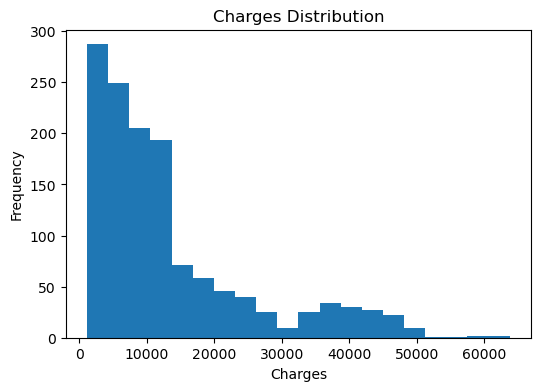

In [9]:
plt.figure(figsize=(6,4))

plt.hist(df["charges"], bins=20)

plt.title("Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

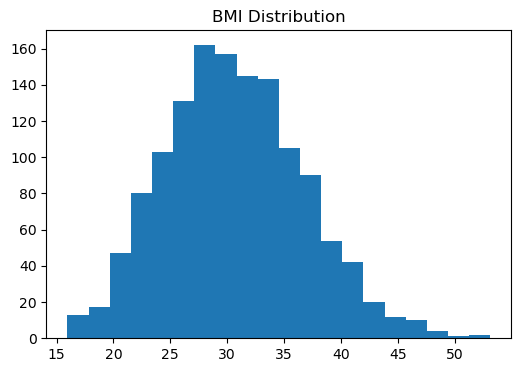

In [10]:
plt.figure(figsize=(6,4))

plt.hist(df["bmi"], bins=20)

plt.title("BMI Distribution")

plt.show()

In [11]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

In [12]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results[name] = r2_score(y_test, pred)

    print(name, "R2 Score:", results[name])

Linear Regression R2 Score: 0.7833463107364536
Decision Tree R2 Score: 0.8309769670027721
Random Forest R2 Score: 0.8653861739369313


In [16]:
base_models = [
    ("lr", LinearRegression()),
    ("dt", DecisionTreeRegressor(max_depth=5)),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
]

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge()
)

stack_model.fit(X_train, y_train)

y_pred = stack_model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2581.1234629885903
MSE : 20589603.471427888
RMSE: 4537.57682815706
R²  : 0.8673766717860821


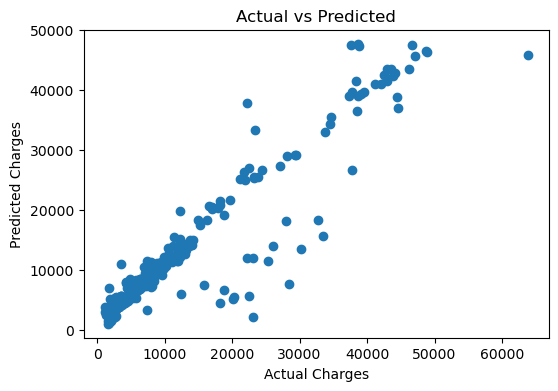

In [18]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()

In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Stacking Regressor"
    ],
    "R2 Score": [
        results["Linear Regression"],
        results["Decision Tree"],
        results["Random Forest"],
        r2
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.783346
1,Decision Tree,0.830977
2,Random Forest,0.865386
3,Stacking Regressor,0.867377


In [20]:
print("Stacking Regression Completed Successfully")
print("Performance compared with individual models")
print("Evaluation metrics generated")

Stacking Regression Completed Successfully
Performance compared with individual models
Evaluation metrics generated
